# Lời giải chi tiết: Bài tập trong `EDA_techniques_tutorial.ipynb`

Mỗi bài gồm:
- **Đề bài** (nhắc lại)
- **Hướng giải** – nghĩ gì trước khi viết code
- **Code + output**
- **Đọc kết quả**
- ✍️ **Câu kết luận** (tiếng Anh, dùng được trong report)
- 💡 **Điều rút ra** – bài học để áp dụng cho bài khác

Notebook có 10 bài tập (đánh số theo bài học: 1, 2, 3, 4, 5, 6, 7, 9, 10, 12).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

data = pd.read_csv("student_habits_performance.csv")
target = "exam_score"
habits = ["study_hours_per_day", "mental_health_rating", "social_media_hours", "netflix_hours",
          "exercise_frequency", "sleep_hours", "attendance_percentage"]
formula = f"{target} ~ " + " + ".join(habits)

df = data.copy()
df["parental_education_level"] = df["parental_education_level"].fillna("Unknown")

---
## Bài tập 1. Viết lại câu *"Categorical features do not matter."*

**Đề bài:** viết lại theo công thức *What → So what → Now what*, dùng p-value, ε² và chênh lệch median.

**Hướng giải.** Câu gốc có 3 vấn đề:
1. **Không có con số** → người đọc không biết "không quan trọng" đến mức nào.
2. **"Matter" mơ hồ** → không quan trọng về mặt *thống kê* (p) hay *thực tế* (effect size)?
3. **Không có hành động tiếp theo** → vậy thì làm gì với các biến này?

Vậy ta cần tính 3 thứ cho cả 6 biến: **p-value** (có phải do ngẫu nhiên?), **ε²** (lớn cỡ nào?), **chênh lệch median lớn nhất** (bao nhiêu điểm, để người đọc hiểu bằng đơn vị thực tế).

In [2]:
cat_cols = ["gender", "part_time_job", "parental_education_level",
            "extracurricular_participation", "diet_quality", "internet_quality"]

rows = []
for col in cat_cols:
    groups = [g[target] for _, g in df.groupby(col)]
    h, p = stats.kruskal(*groups)
    medians = df.groupby(col)[target].median()
    rows.append({
        "feature": col,
        "H": h,
        "p_value": p,
        "epsilon_sq": h / (len(df) - 1),
        "max median gap (points)": medians.max() - medians.min(),
        "highest group": medians.idxmax(),
        "lowest group": medians.idxmin(),
    })

t1 = pd.DataFrame(rows).set_index("feature")
t1["p_holm"] = multipletests(t1["p_value"], method="holm")[1]
t1.sort_values("epsilon_sq", ascending=False)

,H,p_value,epsilon_sq,max median gap (points),highest group,lowest group,p_holm
feature,,,,,,,
internet_quality,3.221,0.200,0.003,2.100,Poor,Good,1.000
parental_education_level,3.163,0.367,0.003,4.900,Bachelor,Master,1.000
diet_quality,2.460,0.292,0.002,3.600,Fair,Poor,1.000
part_time_job,0.920,0.337,0.001,1.400,No,Yes,1.000
gender,0.150,0.928,0.000,1.700,Female,Other,1.000
extracurricular_participation,0.010,0.922,0.000,0.300,Yes,No,1.000


In [3]:
sd = df[target].std()
print(f"SD of exam score = {sd:.1f}")
print(f"Largest median gap = {t1['max median gap (points)'].max():.1f} points "
      f"= {t1['max median gap (points)'].max() / sd:.2f} SD")
print(f"Smallest p = {t1['p_value'].min():.3f} | largest epsilon² = {t1['epsilon_sq'].max():.4f}")

SD of exam score = 16.9
Largest median gap = 4.9 points = 0.29 SD
Smallest p = 0.200 | largest epsilon² = 0.0032


**Đọc kết quả**
- p nhỏ nhất = 0.20 → không biến nào significant, kể cả **trước** khi hiệu chỉnh Holm.
- ε² lớn nhất ≈ 0.003 → **negligible** (ngưỡng "small" là 0.01).
- Chênh lệch median lớn nhất là 4.9 điểm (parental education: Bachelor 71.7 vs Master 66.8) ≈ **0.29 SD** — nhỏ, và lại **ngược chiều** với kỳ vọng (phụ huynh Master thấp nhất) → nhiều khả năng là ngẫu nhiên.

✍️ **Câu kết luận**

> **(What)** None of the six categorical variables is significantly associated with exam score (Kruskal–Wallis, all p ≥ 0.20), and all effect sizes are negligible (ε² ≤ 0.003). The largest difference between group medians is only 4.9 points (parental education: Bachelor 71.7 vs Master 66.8), less than one-third of a standard deviation, and it does not follow the expected order.
> **(So what)** In this dataset, exam performance depends on students' habits rather than on their background.
> **(Now what)** These variables are candidates for removal from the predictive model; §5.3 tests this formally with a nested F-test.

💡 **Điều rút ra:** một kết luận "không có quan hệ" cũng cần **bằng chứng định lượng** như một kết luận "có quan hệ". Luôn cho người đọc biết *"không đáng kể"* là **bao nhiêu**.

---
## Bài tập 2. Nếu nhóm thiếu có điểm TB 62, nhóm đủ 71, p < 0.001 thì sao?

**Đề bài:** (a) Kết luận loại missing nào? (b) Có nên fill `"Unknown"` không, ghi gì vào limitations?

**Hướng giải.** Đây là câu hỏi giả định, nhưng ta có thể **mô phỏng** nó để thấy hậu quả thật. Ý tưởng: tạo một bản sao dữ liệu, rồi cho học sinh **điểm thấp có khả năng bị thiếu cao hơn**. Sau đó xem:
1. Kiểm định có phát hiện được không?
2. Nếu ta **xoá** các dòng thiếu thì kết quả bị **lệch** thế nào?
3. Nếu ta **điền mode** thì so sánh giữa các nhóm bị ảnh hưởng thế nào?

In [4]:
rng = np.random.default_rng(7)
sim = data.drop(columns="parental_education_level").copy()
sim["parental_education_level"] = data["parental_education_level"].fillna("High School")  # giả sử biết giá trị thật

# Xác suất bị thiếu: điểm càng thấp càng dễ bị thiếu (khoảng 25% ở điểm thấp, ~2% ở điểm cao)
prob_missing = np.interp(sim[target], [20, 100], [0.25, 0.02])
missing_mask = rng.random(len(sim)) < prob_missing
sim["pe_observed"] = sim["parental_education_level"].where(~missing_mask)   # NaN nếu bị thiếu

print(f"Số dòng bị thiếu (mô phỏng): {missing_mask.sum()} ({missing_mask.mean():.1%})")
g_miss, g_obs = sim.loc[missing_mask, target], sim.loc[~missing_mask, target]
print(f"Điểm TB nhóm thiếu = {g_miss.mean():.1f} | nhóm đủ = {g_obs.mean():.1f} | "
      f"Mann–Whitney p = {stats.mannwhitneyu(g_miss, g_obs).pvalue:.2e}")

Số dòng bị thiếu (mô phỏng): 119 (11.9%)
Điểm TB nhóm thiếu = 59.0 | nhóm đủ = 71.0 | Mann–Whitney p = 2.56e-12


In [5]:
# Hậu quả 1: XOÁ dòng thiếu -> ước lượng điểm trung bình bị lệch lên
true_mean = sim[target].mean()
cc_mean = sim.loc[~missing_mask, target].mean()
print(f"Điểm TB thật (toàn bộ)          = {true_mean:.2f}")
print(f"Điểm TB sau khi xoá dòng thiếu  = {cc_mean:.2f}  (lệch {cc_mean - true_mean:+.2f})")

# Hậu quả 2: 'Unknown' trở thành một nhóm MANG THÔNG TIN
sim["pe_unknown"] = sim["pe_observed"].fillna("Unknown")
print("\nMedian điểm theo nhóm khi dùng 'Unknown':")
print(sim.groupby("pe_unknown")[target].median().round(1).to_string())

Điểm TB thật (toàn bộ)          = 69.60
Điểm TB sau khi xoá dòng thiếu  = 71.04  (lệch +1.44)

Median điểm theo nhóm khi dùng 'Unknown':
pe_unknown
Bachelor      72.700
High School   70.900
Master        69.600
Unknown       59.800


**Đọc kết quả**
- Mô phỏng tạo ra 119 dòng thiếu (11.9%) với điểm TB **59.0 vs 71.0**, rất gần tình huống đề bài. Kiểm định phát hiện rất rõ (p ≈ 3 × 10⁻¹²) → **không phải MCAR**.
- **Xoá** dòng thiếu làm điểm TB tăng từ 69.6 lên 71.0 (**+1.4 điểm**): ta đánh giá học sinh **giỏi hơn thực tế**, vì đã loại bỏ nhiều học sinh điểm thấp một cách có hệ thống.
- Khi dùng `"Unknown"`, nhóm này có median **59.8**, thấp hơn hẳn các nhóm khác (69.6–72.7). Tức là *việc bị thiếu* đã **mang thông tin** về điểm.

**Trả lời**

**(a)** Dữ liệu **không phải MCAR**. Có hai khả năng:
- **MAR** – nếu sự khác biệt được giải thích bởi biến khác mà ta quan sát được (ví dụ nhóm thiếu học ít giờ hơn). Kiểm tra: lặp lại kiểm định MCAR cho `study_hours_per_day`, v.v. Nếu nhóm thiếu học ít hơn hẳn thì nhiều khả năng là MAR.
- **MNAR** – nếu thiếu phụ thuộc vào chính học vấn phụ huynh (ví dụ phụ huynh học vấn thấp ngại khai). Không thể kiểm chứng từ dữ liệu, chỉ có thể lập luận.

**(b)**
- ✅ **Vẫn nên giữ `"Unknown"` như một nhóm riêng**: không mất 9% dữ liệu, và mô hình có thể *dùng* thông tin "bị thiếu".
- ❌ **Không** xoá dòng (làm lệch kết quả, như mô phỏng cho thấy).
- ❌ **Không** điền mode ("High School"), vì như vậy nhóm High School sẽ bị trộn lẫn với nhóm có điểm thấp hơn → so sánh giữa các mức học vấn bị sai.
- Nếu nghi ngờ MAR: có thể dùng **multiple imputation** dựa trên các biến khác (nâng cao, không bắt buộc trong EDA).

✍️ **Câu cho phần Limitations**
> *Students with missing parental education score substantially lower than the others (62 vs 71, p < 0.001), so the missingness is not random. Missing values were kept as a separate "Unknown" category rather than deleted or imputed, but comparisons between parental-education levels may still be biased and should be interpreted with caution.*

💡 **Điều rút ra:** câu hỏi quan trọng không phải *"thiếu bao nhiêu %?"* mà là *"**ai** bị thiếu?"*. 9% thiếu ngẫu nhiên thì vô hại; 9% thiếu có hệ thống có thể làm sai toàn bộ kết luận.

---
## Bài tập 3. Nghĩ thêm một cross-variable rule và viết code kiểm tra

**Đề bài:** thêm một rule khác. `attendance = 100` và `study = 0` có vô lý không?

**Hướng giải.** Phân biệt hai loại:

| Loại | Định nghĩa | Hành động |
|---|---|---|
| **Hard rule (vi phạm)** | Không thể xảy ra trong thực tế | Sửa hoặc xoá, ghi vào decision log |
| **Soft rule (đáng chú ý)** | Có thể xảy ra nhưng hiếm/lạ | Đếm, báo cáo, **giữ lại** |

`attendance = 100%` + `study = 0 giờ tự học` là **có thể xảy ra** (đi học đầy đủ nhưng không học thêm ở nhà) → đây là **soft rule**.

Mình đề xuất thêm 4 rule, mỗi loại 2 cái:

In [6]:
screen = data["social_media_hours"] + data["netflix_hours"]
awake = 24 - data["sleep_hours"]

hard_rules = {
    # Hard: không thể xảy ra
    "H1: screen time <= awake time": screen <= awake,
    "H2: sleep >= 2 h/day": data["sleep_hours"] >= 2,
}
soft_rules = {
    # Soft: có thể xảy ra nhưng đáng chú ý
    "S1: attendance = 100 AND study = 0": (data["attendance_percentage"] == 100) & (data["study_hours_per_day"] == 0),
    "S2: study >= 6 h AND score < 50": (data["study_hours_per_day"] >= 6) & (data[target] < 50),
    "S3: screen time > study + 4 h AND score = 100": (screen > data["study_hours_per_day"] + 4) & (data[target] == 100),
}

print("HARD rules – number of VIOLATIONS")
for name, ok in hard_rules.items():
    print(f"  {name:45s}: {(~ok).sum()}")

print("\nSOFT rules – number of FLAGGED rows")
for name, flag in soft_rules.items():
    print(f"  {name:45s}: {flag.sum()}")

HARD rules – number of VIOLATIONS
  H1: screen time <= awake time                : 0
  H2: sleep >= 2 h/day                         : 0

SOFT rules – number of FLAGGED rows
  S1: attendance = 100 AND study = 0           : 0
  S2: study >= 6 h AND score < 50              : 0
  S3: screen time > study + 4 h AND score = 100: 0


In [7]:
# Luôn xem cụ thể các dòng bị flag (nếu có) trước khi quyết định
flag_any = pd.concat(soft_rules, axis=1).any(axis=1)
data.loc[flag_any, ["study_hours_per_day", "social_media_hours", "netflix_hours",
                    "attendance_percentage", "exam_score"]]

,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,exam_score


**Đọc kết quả**
- Hard rules: **0 vi phạm** → không có giá trị bất khả thi.
- Soft rules: **cũng 0 dòng bị flag**. Với dữ liệu khảo sát thật, gần như luôn có vài câu trả lời "kỳ lạ" (người trả lời bừa, nhập nhầm…). Việc dữ liệu "sạch hoàn hảo" như vậy **cũng là một dấu hiệu** cho thấy dữ liệu được mô phỏng.
- Nếu có dòng bị flag, ta **giữ lại** nhưng ghi nhận. Nếu có rất nhiều, đó có thể là dấu hiệu dữ liệu kém chất lượng.

✍️ **Câu kết luận**
> *In addition to single-variable range checks, two cross-variable rules were applied (screen time cannot exceed waking time; sleep must be at least 2 hours), with no violations. Three "unusual but possible" combinations (e.g. studying 6+ hours but scoring below 50) were also checked, and no rows were flagged. Such perfectly clean data is uncommon in real surveys and is consistent with the dataset being simulated.*

💡 **Điều rút ra:** Trong decision log, tách rõ **"invalid"** (sửa/xoá) và **"unusual"** (giữ, ghi chú). Giảng viên đánh giá cao việc bạn **không xoá dữ liệu chỉ vì nó lạ**.

---
## Bài tập 4. Học sinh đạt 100 điểm học trung bình bao nhiêu giờ/ngày?

**Hướng giải.** So sánh phân phối `study_hours_per_day` của nhóm 100 điểm với nhóm còn lại, bằng cả **số liệu** và **biểu đồ**. Câu hỏi sâu hơn: nhóm 100 điểm có **khác biệt gì** so với nhóm "gần 100" (90–99.9)? Nếu điểm bị cắt, hai nhóm này lẽ ra phải khá giống nhau, nhưng nhóm 100 phải "giỏi hơn một chút".

In [8]:
groups4 = pd.cut(data[target], bins=[0, 89.99, 99.99, 100], labels=["< 90", "90–99.9", "= 100"])
t4 = data.groupby(groups4, observed=True)[habits].mean().T
t4["all students"] = data[habits].mean()
t4

exam_score,< 90,90–99.9,= 100,all students
study_hours_per_day,3.249,5.272,6.235,3.550
mental_health_rating,5.219,6.872,7.104,5.438
social_media_hours,2.538,2.291,2.254,2.506
netflix_hours,1.857,1.645,1.431,1.820
exercise_frequency,2.935,3.526,4.208,3.042
sleep_hours,6.434,6.637,6.850,6.470
attendance_percentage,83.747,86.829,86.758,84.132


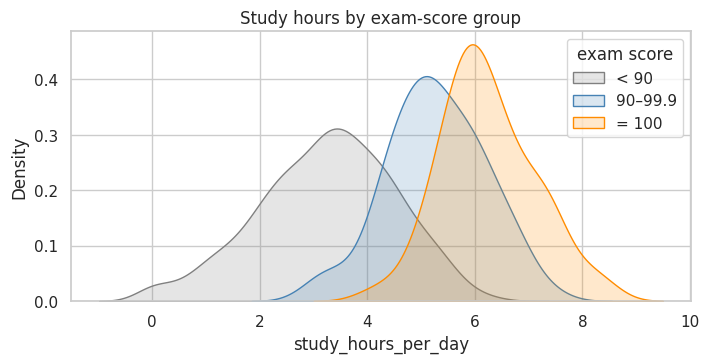

Score = 100: n = 48, mean = 6.24 h, median = 6.10 h, min = 4.2 h
All students: mean = 3.55 h


In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for label, color in zip(["< 90", "90–99.9", "= 100"], ["grey", "steelblue", "darkorange"]):
    sns.kdeplot(data.loc[groups4 == label, "study_hours_per_day"], ax=ax, label=label, color=color, fill=True, alpha=0.2)
ax.set_title("Study hours by exam-score group")
ax.legend(title="exam score")
plt.show()

s100 = data.loc[data[target] == 100, "study_hours_per_day"]
print(f"Score = 100: n = {len(s100)}, mean = {s100.mean():.2f} h, median = {s100.median():.2f} h, min = {s100.min()} h")
print(f"All students: mean = {data.study_hours_per_day.mean():.2f} h")

**Đọc kết quả**
- Nhóm 100 điểm học trung bình **≈ 6.2 giờ/ngày**, gần **gấp đôi** trung bình chung (3.55 giờ). Ít nhất là 4.2 giờ.
- Nhóm 90–99.9 cũng học nhiều, nhưng nhóm 100 học **nhiều hơn** và phân phối lệch hẳn về bên phải.
- Nhóm 100 cũng có mental health cao hơn (7.1 vs 5.4), tập thể dục nhiều hơn (4.2 vs 3.0 ngày/tuần), xem Netflix ít hơn (1.4 vs 1.8 giờ) → đây là những học sinh có **tất cả** thói quen tốt; nhiều em "đáng lẽ" được > 100 nếu thang điểm không bị cắt.

✍️ **Câu kết luận**
> *Students who scored exactly 100 study about 6.2 hours per day on average — nearly twice the overall mean (3.55 h) — and also report better mental health, more exercise and less Netflix. Because the score is capped, many of these students would probably have scored above 100, which confirms the ceiling effect.*

💡 **Điều rút ra:** khi thấy một nhóm đặc biệt (ceiling, outlier, missing), hãy **mô tả nhóm đó** trên các biến khác. Việc này biến một "vấn đề dữ liệu" thành một **insight**.

---
## Bài tập 5. `sleep_hours` có r = 0.12. Tính r² và viết kết luận.

**Hướng giải.** r² = r × r = % variance của điểm được giải thích bởi giấc ngủ (khi xét riêng). Viết kết luận có **cả** p-value **và** effect size. Nâng cao: dùng lại ý tưởng Bài 9 để cho thấy tác động thật sự lớn hơn.

In [10]:
r, p = stats.pearsonr(data["sleep_hours"], data[target])
print(f"r = {r:.3f} | r² = {r**2:.4f} ({r**2*100:.1f}% of variance) | p = {p:.2e}")

# Diễn giải bằng đơn vị thực tế: slope của hồi quy đơn
slope = smf.ols(f"{target} ~ sleep_hours", data=data).fit().params["sleep_hours"]
print(f"Simple regression: +1 hour of sleep -> {slope:+.2f} points")

# Nâng cao: sau khi kiểm soát giờ học
resid = smf.ols(f"{target} ~ study_hours_per_day", data=data).fit().resid
r_adj = stats.pearsonr(data["sleep_hours"], resid)[0]
print(f"After removing study hours: r = {r_adj:.3f}")

r = 0.122 | r² = 0.0148 (1.5% of variance) | p = 1.15e-04
Simple regression: +1 hour of sleep -> +1.68 points
After removing study hours: r = 0.256


**Đọc kết quả**
- r² ≈ 0.015 → giấc ngủ **khi xét riêng** chỉ giải thích **≈ 1.5%** sự khác biệt về điểm.
- Mỗi giờ ngủ thêm gắn với ≈ **+1.7 điểm** (hồi quy đơn).
- Sau khi loại ảnh hưởng của giờ học, r tăng gấp đôi lên ≈ 0.26 → hiệu ứng bị **che khuất**.

✍️ **Câu kết luận (mức cơ bản)**
> *Sleep hours has a weak positive association with exam score (r = 0.12, p < 0.001). Although statistically significant, on its own it explains only about 1.5% of the variance in scores (r² = 0.015).*

✍️ **Câu kết luận (mức HD – thêm 1 câu)**
> *However, once study time is accounted for, the association doubles (r = 0.26), suggesting that the effect of sleep is partly masked by the much larger effect of study time (see §5.3).*

💡 **Điều rút ra:** "weak" trong correlation không có nghĩa là "không quan trọng". Hãy kiểm tra xem nó có bị biến khác **che khuất** không.

---
## Bài tập 6. Hiệu chỉnh Holm cho bảng MCAR. Attendance còn significant không?

**Hướng giải.** Tính lại bảng MCAR (14 kiểm định), đưa cả danh sách p-value vào `multipletests(..., method="holm")`. Làm thêm **bằng tay** cho 3 dòng đầu để hiểu Holm hoạt động thế nào.

In [11]:
is_missing = data["parental_education_level"].isna()
num_cols = data.select_dtypes("number").columns
other_cats = [c for c in cat_cols if c != "parental_education_level"]

rows = []
for col in num_cols:
    rows.append([col, "Mann-Whitney", stats.mannwhitneyu(data.loc[is_missing, col], data.loc[~is_missing, col]).pvalue])
for col in other_cats:
    rows.append([col, "Chi-square", stats.chi2_contingency(pd.crosstab(is_missing, data[col]))[1]])

mcar = pd.DataFrame(rows, columns=["variable", "test", "p_value"]).sort_values("p_value").reset_index(drop=True)
reject, p_holm, _, _ = multipletests(mcar["p_value"], alpha=0.05, method="holm")
mcar["p_holm"] = p_holm
mcar["significant after Holm"] = reject
mcar

,variable,test,p_value,p_holm,significant after Holm
0,attendance_percentage,Mann-Whitney,0.018,0.245,False
1,gender,Chi-square,0.240,1.000,False
2,netflix_hours,Mann-Whitney,0.277,1.000,False
3,mental_health_rating,Mann-Whitney,0.317,1.000,False
4,age,Mann-Whitney,0.330,1.000,False
5,study_hours_per_day,Mann-Whitney,0.376,1.000,False
6,exercise_frequency,Mann-Whitney,0.622,1.000,False
7,internet_quality,Chi-square,0.693,1.000,False
8,diet_quality,Chi-square,0.699,1.000,False
9,exam_score,Mann-Whitney,0.708,1.000,False


In [12]:
# Tự tính bằng tay cho 3 dòng đầu: so sánh p_k với alpha / (m - k)
m = len(mcar)
for k in range(3):
    p_k = mcar.loc[k, "p_value"]
    thr = 0.05 / (m - k)
    print(f"rank {k+1}: {mcar.loc[k, 'variable']:25s} p = {p_k:.4f} vs 0.05/{m-k} = {thr:.4f} "
          f"-> {'reject' if p_k <= thr else 'STOP (not significant)'}")
    if p_k > thr:
        break

# Holm-adjusted p cũng có thể hiểu là: p × (m − k), lấy giá trị lớn nhất tích luỹ, tối đa 1
print(f"\nAdjusted p for attendance = {mcar.loc[0, 'p_value']:.4f} × {m} = {mcar.loc[0, 'p_value'] * m:.3f}")

rank 1: attendance_percentage     p = 0.0175 vs 0.05/14 = 0.0036 -> STOP (not significant)

Adjusted p for attendance = 0.0175 × 14 = 0.245


**Đọc kết quả**
- Có m = 14 kiểm định. Attendance có p nhỏ nhất (0.018), nên phải so với ngưỡng chặt nhất: **0.05 / 14 = 0.0036**. 0.018 > 0.0036 → **dừng ngay**, không biến nào significant.
- p đã hiệu chỉnh của attendance = 0.018 × 14 ≈ **0.25**.

**Trả lời:** attendance **không còn significant** sau Holm correction.

Kiểm tra thêm bằng **effect size**: attendance TB của nhóm thiếu là 86.6% so với 83.9% ở nhóm đủ, chênh 2.8 điểm phần trăm, ≈ 0.3 SD. Chênh lệch nhỏ, không có lý do hợp lý nào (tại sao thiếu thông tin phụ huynh lại đi học nhiều hơn?) → nhiều khả năng là **false positive**.

✍️ **Câu kết luận**
> *Only attendance showed a nominal difference between students with and without parental-education data (p = 0.018). After Holm correction for 14 tests, this difference is not significant (adjusted p = 0.25), so there is no evidence against the data being missing completely at random.*

💡 **Điều rút ra:** chạy 14 test mà có 1 cái p < 0.05 là **bình thường** (kỳ vọng ≈ 14 × 0.05 = 0.7 cái do ngẫu nhiên). Đừng kể một câu chuyện từ một p-value lẻ loi.

---
## Bài tập 7. Bảng binning cho `social_media_hours` với `pd.qcut(..., 5)`

**Hướng giải.** `qcut` chia thành 5 nhóm có **số học sinh xấp xỉ bằng nhau** (quintile). Tính điểm TB mỗi nhóm và mức giảm giữa các nhóm. Để có góc nhìn, làm **song song** cho `study_hours_per_day` và so sánh độ rộng giữa nhóm thấp nhất và cao nhất.

In [13]:
def quintile_table(col):
    q = pd.qcut(data[col], 5)
    t = data.groupby(q, observed=True).agg(n=(target, "count"),
                                           mean_hours=(col, "mean"),
                                           mean_score=(target, "mean"))
    t["change vs previous"] = t["mean_score"].diff()
    return t

t7 = quintile_table("social_media_hours")
t7

,n,mean_hours,mean_score,change vs previous
social_media_hours,,,,
"(-0.001, 1.5]",214,0.914,73.618,NaN
"(1.5, 2.2]",211,1.926,71.689,-1.929
"(2.2, 2.84]",175,2.541,69.511,-2.178
"(2.84, 3.5]",218,3.167,66.812,-2.698
"(3.5, 7.2]",182,4.221,65.887,-0.926


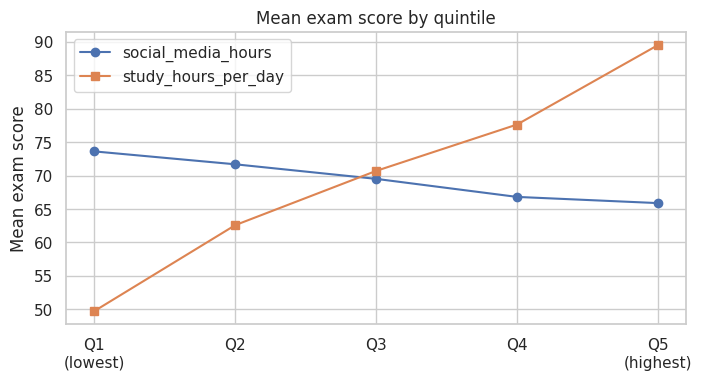

Social media: Q1 -> Q5 = -7.7 points
Study hours : Q1 -> Q5 = +39.8 points


In [14]:
t7_study = quintile_table("study_hours_per_day")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(range(1, 6), t7["mean_score"], marker="o", label="social_media_hours")
ax.plot(range(1, 6), t7_study["mean_score"], marker="s", label="study_hours_per_day")
ax.set_xticks(range(1, 6), ["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"])
ax.set_ylabel("Mean exam score")
ax.set_title("Mean exam score by quintile")
ax.legend()
plt.show()

print(f"Social media: Q1 -> Q5 = {t7['mean_score'].iloc[-1] - t7['mean_score'].iloc[0]:+.1f} points")
print(f"Study hours : Q1 -> Q5 = {t7_study['mean_score'].iloc[-1] - t7_study['mean_score'].iloc[0]:+.1f} points")

**Đọc kết quả**
- Điểm TB **giảm dần đều** qua 5 nhóm: từ ≈ 73.6 (≈ 0.9 giờ mạng xã hội/ngày) xuống ≈ 65.9 (≈ 4.2 giờ/ngày). Mỗi nhóm giảm 1–3 điểm, tổng cộng **≈ −8 điểm**.
- Để so sánh, với study hours thì Q1 → Q5 **tăng khoảng 40 điểm**. Biểu đồ cho thấy rõ: đường social media gần như nằm ngang so với đường study.
- Q4 → Q5 chỉ giảm ≈ 1 điểm, nhưng Q5 là nhóm rộng (3.5–7.2 giờ) với ít học sinh ở mức rất cao → không đủ bằng chứng để nói hiệu ứng "bão hoà".

✍️ **Câu kết luận**
> *Mean exam score decreases steadily across social-media quintiles, from 73.6 for the lightest users (about 0.9 h/day) to 65.9 for the heaviest (about 4.2 h/day) — a drop of about 8 points. The effect is consistent but much smaller than that of study time, where the gap between the lowest and highest quintiles is about 40 points.*

💡 **Điều rút ra:** `qcut` tốt khi muốn nhóm **cân bằng số lượng** (so sánh công bằng); `cut` tốt khi muốn mốc **dễ hiểu** (0–1 giờ, 1–2 giờ…). Luôn đặt biến yếu **cạnh** biến mạnh để người đọc thấy tỷ lệ.

---
## Bài tập 9. Tính "r after removing study hours" cho social media và Netflix. Cái nào bị che khuất nhiều hơn?

**Hướng giải.** Lặp lại cách làm ở Bài 9: lấy residual sau khi hồi quy theo giờ học, rồi tính tương quan. Đo mức "che khuất" bằng **tỷ lệ** `|r sau| / |r trước|`. Kiểm tra lại bằng hệ số chuẩn hoá trong mô hình đầy đủ.

In [15]:
resid_after_study = smf.ols(f"{target} ~ study_hours_per_day", data=data).fit().resid

rows = []
for col in habits[1:]:
    r_raw = stats.pearsonr(data[col], data[target])[0]
    r_adj = stats.pearsonr(data[col], resid_after_study)[0]
    rows.append([col, r_raw, r_adj, abs(r_adj) / abs(r_raw)])
t9 = pd.DataFrame(rows, columns=["feature", "r raw", "r after study", "ratio"]).set_index("feature")

# Kiểm tra chéo với standardised beta trong mô hình đầy đủ
z = data[habits + [target]].apply(lambda s: (s - s.mean()) / s.std())
t9["std. beta (full model)"] = smf.ols(formula, data=z).fit().params[habits[1:]]
t9.sort_values("ratio", ascending=False)

,r raw,r after study,ratio,std. beta (full model)
feature,,,,
sleep_hours,0.122,0.256,2.105,0.146
exercise_frequency,0.160,0.326,2.034,0.174
social_media_hours,-0.167,-0.325,1.949,-0.182
mental_health_rating,0.322,0.575,1.789,0.329
netflix_hours,-0.172,-0.259,1.506,-0.145
attendance_percentage,0.090,0.121,1.344,0.081


**Đọc kết quả** (tập trung vào 2 biến được hỏi)

| | r raw | r after study | ratio | std. β |
|---|---|---|---|---|
| social_media_hours | −0.167 | **−0.325** | ≈ 1.95 | −0.18 |
| netflix_hours | −0.172 | −0.259 | ≈ 1.51 | −0.15 |

- Khi xét riêng, Netflix trông **mạnh hơn một chút** (−0.172 vs −0.167).
- Sau khi loại bỏ giờ học, **social media mạnh hơn rõ rệt** (−0.33 vs −0.26), và β trong mô hình đầy đủ cũng xác nhận (−0.18 vs −0.15).
- → **Social media bị che khuất nhiều hơn** (tăng ≈ gấp 2 so với ≈ 1.5).

**Tại sao mọi biến đều "mạnh lên"?** Residual sau khi loại giờ học chỉ còn √(1 − 0.68) ≈ 0.565 lần độ lệch chuẩn ban đầu. Cùng một tác động, chia cho một mẫu số nhỏ hơn thì r lớn hơn: tỷ lệ "nền" là 1 / 0.565 ≈ **1.77**. Biến nào có ratio **lớn hơn 1.77** thì bị che khuất nhiều hơn mức nền; biến nào **nhỏ hơn** thì một phần tương quan ban đầu của nó thực ra "mượn" từ giờ học.

**Tại sao social media và Netflix khác nhau?** Xem bảng tương quan ở ô dưới: Netflix tương quan **−0.031** với giờ học, social media là **+0.020**.
- Netflix: một phần nhỏ của r ban đầu (≈ 0.825 × −0.031 ≈ **−0.026**) đến từ con đường *"xem Netflix nhiều ↔ học ít hơn một chút ↔ điểm thấp"*. Khi loại giờ học ra, phần này mất đi → ratio chỉ **1.51** (< 1.77).
- Social media thì ngược lại: con đường qua giờ học (+0.017) đang **che bớt** tác động âm của nó → khi loại ra, tác động thật lộ rõ → ratio **1.95** (> 1.77).

Các tương quan −0.03 và +0.02 rất nhỏ, nhưng vì giờ học có tác động quá lớn (r = 0.825), chúng đủ để **đảo thứ hạng** giữa hai biến.

✍️ **Câu kết luận**
> *In the simple correlations, Netflix and social media look equally harmful (r ≈ −0.17). After removing the effect of study time, social media shows the stronger association (r = −0.33 vs −0.26), which is confirmed by the standardised coefficients in the full model (β = −0.18 vs −0.15). The simple correlations therefore understate the importance of social media.*

💡 **Điều rút ra:** thứ hạng giữa các biến có thể **đổi** khi kiểm soát biến khác. Không bao giờ xếp hạng "feature importance" chỉ bằng correlation đơn.

In [16]:
# Kiểm tra lời giải thích: tương quan giữa study hours và 2 biến kia
data[["study_hours_per_day", "social_media_hours", "netflix_hours"]].corr().round(3)

,study_hours_per_day,social_media_hours,netflix_hours
study_hours_per_day,1.000,0.020,-0.031
social_media_hours,0.020,1.000,0.011
netflix_hours,-0.031,0.011,1.000


---
## Bài tập 10. So sánh M1 (`exam_score ~ study_hours_per_day`) và M2 (7 thói quen) bằng `anova_lm`

**Hướng giải.** M1 lồng trong M2 (M2 = M1 + 6 biến). F-test kiểm tra: 6 biến thêm vào có giảm sai số đáng kể không? Báo cáo thêm R², adj R², RMSE để thấy **mức độ** cải thiện (effect size), không chỉ p-value.

In [17]:
m1 = smf.ols(f"{target} ~ study_hours_per_day", data=data).fit()
m2 = smf.ols(formula, data=data).fit()

print(anova_lm(m1, m2))
print()
print(pd.DataFrame({
    "R2": [m1.rsquared, m2.rsquared],
    "adj R2": [m1.rsquared_adj, m2.rsquared_adj],
    "RMSE": [np.sqrt(m1.mse_resid), np.sqrt(m2.mse_resid)],
}, index=["M1: study only", "M2: 7 habits"]))

   df_resid       ssr  df_diff   ss_diff       F  Pr(>F)
0   998.000 90805.380    0.000       NaN     NaN     NaN
1   992.000 28188.684    6.000 62616.696 367.262   0.000

                  R2  adj R2  RMSE
M1: study only 0.681   0.681 9.539
M2: 7 habits   0.901   0.900 5.331


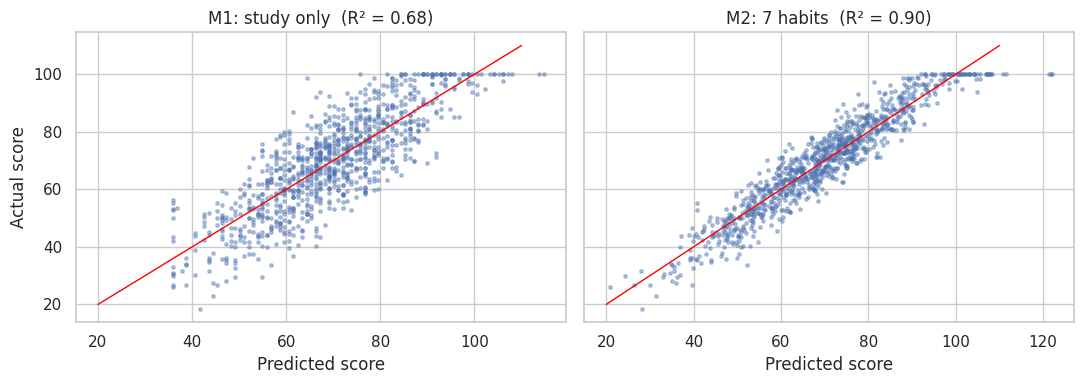

In [18]:
# Trực quan: dự đoán vs thực tế của 2 mô hình
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, m, name in zip(axes, [m1, m2], ["M1: study only", "M2: 7 habits"]):
    ax.scatter(m.fittedvalues, data[target], s=6, alpha=0.4)
    ax.plot([20, 110], [20, 110], color="red", lw=1)
    ax.set_title(f"{name}  (R² = {m.rsquared:.2f})")
    ax.set_xlabel("Predicted score")
axes[0].set_ylabel("Actual score")
plt.tight_layout()
plt.show()

**Đọc kết quả**
- F ≈ 367 với 6 bậc tự do, p < 0.001 → 6 thói quen thêm vào cải thiện mô hình **rất đáng kể**.
- R² tăng từ **0.68 → 0.90**: giải thích thêm 22% variance. RMSE giảm từ **9.5 → 5.3 điểm** (sai số giảm gần một nửa).
- Biểu đồ: các điểm của M2 bám **sát** đường chéo hơn hẳn M1.

So sánh với nested test ở Bài 10 (M2 vs M3): thêm 12 biến nền → F = 0.64, p = 0.81, không cải thiện. Hai test này cùng nhau trả lời trọn vẹn **RQ5**: *giữ 7 thói quen, bỏ biến nền*.

✍️ **Câu kết luận**
> *Although study time alone explains 68% of the variance, adding the other six habits significantly improves the model (F(6, 992) = 367, p < 0.001), increasing R² to 0.90 and reducing the typical prediction error from 9.5 to 5.3 points. All seven habit features should therefore be retained.*

💡 **Điều rút ra:** dùng nested F-test theo **cả hai chiều**: một lần để chứng minh nhóm biến **đáng giữ**, một lần để chứng minh nhóm biến **nên bỏ**. Kết hợp với adj R²/RMSE để báo cáo mức độ.

---
## Bài tập 12. Test interaction `study_hours_per_day:sleep_hours`

**Hướng giải.**
1. **Lý do hợp lý trước khi test** (tránh "câu cá"): ngủ đủ có thể giúp não ghi nhớ tốt hơn → mỗi giờ học *hiệu quả hơn* ở người ngủ nhiều? Nếu đúng, hệ số interaction sẽ **dương**.
2. Thêm `study_hours_per_day:sleep_hours` vào mô hình đầy đủ; xem hệ số, p-value, gain in adj R².
3. Trực quan: chia sleep thành 3 nhóm và vẽ đường hồi quy study → score cho từng nhóm. Nếu **song song** → không có interaction.

In [19]:
m12 = smf.ols(formula + " + study_hours_per_day:sleep_hours", data=data).fit()
term = "study_hours_per_day:sleep_hours"
lo, hi = m12.conf_int().loc[term]
print(f"Interaction coef = {m12.params[term]:.3f}  (95% CI {lo:.3f} to {hi:.3f}),  p = {m12.pvalues[term]:.3f}")
print(f"adj R²: {m2.rsquared_adj:.4f} -> {m12.rsquared_adj:.4f}  (gain {m12.rsquared_adj - m2.rsquared_adj:+.4f})")

# Ý nghĩa thực tế: độ dốc của study hours ở người ngủ 5h vs 8h
b_study = m12.params["study_hours_per_day"]
b_int = m12.params[term]
for s in [5, 8]:
    print(f"Slope of study hours when sleep = {s} h: {b_study + b_int * s:.2f} points per hour")

Interaction coef = -0.058  (95% CI -0.244 to 0.127),  p = 0.537
adj R²: 0.9004 -> 0.9003  (gain -0.0001)
Slope of study hours when sleep = 5 h: 9.66 points per hour
Slope of study hours when sleep = 8 h: 9.49 points per hour


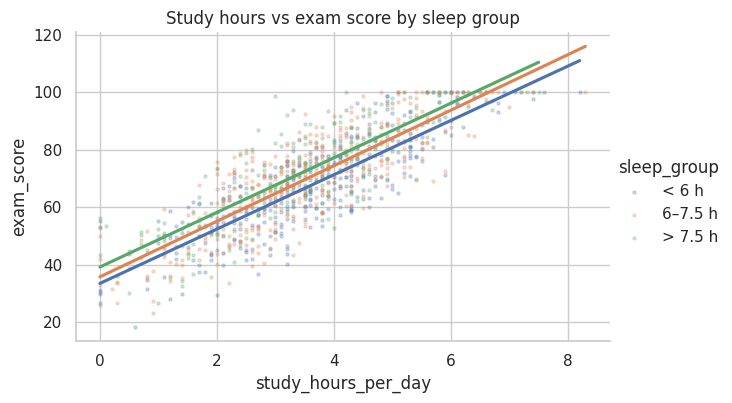

In [20]:
plot_df = data.assign(sleep_group=pd.cut(data["sleep_hours"], [0, 6, 7.5, 12],
                                         labels=["< 6 h", "6–7.5 h", "> 7.5 h"]))
sns.lmplot(data=plot_df, x="study_hours_per_day", y=target, hue="sleep_group",
           scatter_kws={"s": 5, "alpha": 0.25}, height=4, aspect=1.6, ci=None)
plt.title("Study hours vs exam score by sleep group")
plt.show()

**Đọc kết quả**
- Hệ số ≈ −0.06, khoảng tin cậy 95% (−0.24 đến 0.13) **chứa 0**, p ≈ 0.54 → **không significant**.
- adj R² **không tăng** (thậm chí giảm nhẹ) → thêm interaction chỉ làm mô hình phức tạp hơn mà không tốt hơn.
- Ý nghĩa thực tế: độ dốc của giờ học là ≈ 9.7 điểm/giờ ở người ngủ 5h và ≈ 9.5 ở người ngủ 8h → **gần như giống hệt nhau**.
- Biểu đồ: ba đường **gần như song song**, chỉ lệch nhau theo chiều dọc (người ngủ nhiều hơn có điểm cao hơn một chút ở mọi mức giờ học) → đó là **main effect** của sleep, không phải interaction.
- Giả thuyết ban đầu (ngủ nhiều → học hiệu quả hơn, hệ số dương) **không được ủng hộ**.

✍️ **Câu kết luận**
> *We tested whether the benefit of studying depends on sleep, as better-rested students might learn more efficiently. The interaction is not significant (b = −0.06, 95% CI includes zero, p = 0.54) and does not improve adjusted R². The slope of study time is almost identical for students sleeping 5 or 8 hours (about 9.5–9.7 points per hour). Sleep therefore has an additive effect: it raises scores by a similar amount at every level of study time, and the additive model is retained.*

💡 **Điều rút ra:**
- **Đường song song** = chỉ có main effect; **đường cắt nhau hoặc toả ra** = có interaction.
- Luôn đặt **giả thuyết + chiều kỳ vọng** trước khi test, rồi báo cáo kết quả kể cả khi không có ý nghĩa. Một giả thuyết bị bác bỏ **cũng là một finding**.

---
## Tổng kết: 10 bài tập dạy bạn điều gì?

| Bài | Kỹ năng | Câu hỏi cần tự đặt ra |
|---|---|---|
| 1 | Viết conclusion | *Có con số không? Có "so what" và "now what" không?* |
| 2 | Missing data | ***Ai** bị thiếu, chứ không chỉ thiếu bao nhiêu?* |
| 3 | Domain rules | *Đây là **invalid** hay chỉ **unusual**?* |
| 4 | Ceiling effect | *Nhóm đặc biệt này khác gì trên các biến khác?* |
| 5 | Effect size | *Significant, nhưng **lớn cỡ nào**?* |
| 6 | Multiple testing | *Mình đã chạy **bao nhiêu** test?* |
| 7 | Binning | *Bằng **đơn vị thực tế** thì khác bao nhiêu?* |
| 9 | Masking | *Thứ hạng có **đổi** khi kiểm soát biến khác không?* |
| 10 | Nested F-test | *Nhóm biến này có **đáng** thêm vào không?* |
| 12 | Interaction | *Tác động có **giống nhau** cho mọi người không?* |